### Model Training

In this notebook, we will proceed with training a machine learning model to predict customer churn based on the dataset provided. The dataset has already been cleaned and processed, including label encoding for categorical variables and setting the correct data types. Below are the steps we'll follow:

1. **Load the Dataset:** We'll load the processed dataset into a pandas DataFrame to begin analysis.
2. **Train-Test Split:** Before model training, we will split the dataset into training and testing sets to validate our model.
3. **Model Training:** We will train a classification model (e.g., Logistic Regression, Random Forest) to predict customer churn.
4. **Model Evaluation:** After training, we will evaluate the model's performance using metrics like accuracy, precision, recall, and F1-score.

Let's proceed with loading the data and preparing it for model training.

### **Step 1: Load the Processed Dataset**

Here we'll load the dataset that we previously cleaned and processed, which is now ready for modeling. This dataset includes all the necessary transformations, such as label encoding for categorical variables and correct data types for numerical columns.


In [4]:
# import necessary libraries

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('Telco_customer_churn_processed.xlsx')

### **Step 2: Separate Features and Target Variable**

As the next step, we will separate our features (independent variables) from the target variable (dependent variable). The target variable in this case is the 'Churn Label', which indicates whether a customer has churned or not. We will create two separate variables: `X` for the features and `y` for the target variable. This separation is crucial for training our machine learning model effectively.

In [5]:
X = df.drop(columns=['Churn Label'])
y = df['Churn Label']

### **Step 3: Split Data into Training, Validation, and Test Sets**

Before we train our model, we need to split our dataset into a training set and a testing set. This allows us to evaluate the performance of our model on unseen data, which is crucial for assessing its generalization capabilities. We will split the data by 70:15:15 for training, validation, and testing respectively.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.50, random_state=42)

### **Step 4: Feature Scaling**

In this step, we will apply **feature scaling** to the training dataset. Scaling is important for models that are sensitive to the magnitude of the features (e.g., **Random Forest**, **KNN**, **Logistic Regression**, **SVM**).

#### **What to Do**:
1. **Standard Scaling**: We will scale the features to have a **mean of 0** and a **standard deviation of 1** using **StandardScaler**.
2. **Apply Scaling**: Scaling will be applied to all the as all are **numerical columns** (such as `Tenure Months`, `Monthly Charges`, `Total Charges`, etc.).


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test data using the same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#### **XGBoost**

we'll train an **XGBoost** model, which is a powerful gradient boosting algorithm that often provides excellent performance for classification tasks. XGBoost is known for its efficiency and scalability, making it a popular choice for machine learning competitions and real-world applications.

In [12]:
import xgboost as xgb

# Initialize the XGBoost classifier
model = xgb.XGBClassifier(random_state=42)

# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Evaluate the model on the validation set
y_val_pred = model.predict(X_val_scaled)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# Final evaluation on the test set
y_test_pred = model.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

try:
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    print("Test ROC AUC:", roc_auc_score(y_test, y_test_prob))
except Exception:
    pass

Validation Accuracy: 0.9299242424242424
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       754
           1       0.88      0.88      0.88       302

    accuracy                           0.93      1056
   macro avg       0.91      0.92      0.91      1056
weighted avg       0.93      0.93      0.93      1056

Test Accuracy: 0.9157994323557237
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       771
           1       0.86      0.83      0.84       286

    accuracy                           0.92      1057
   macro avg       0.90      0.89      0.89      1057
weighted avg       0.92      0.92      0.92      1057

Test ROC AUC: 0.9758464622277853


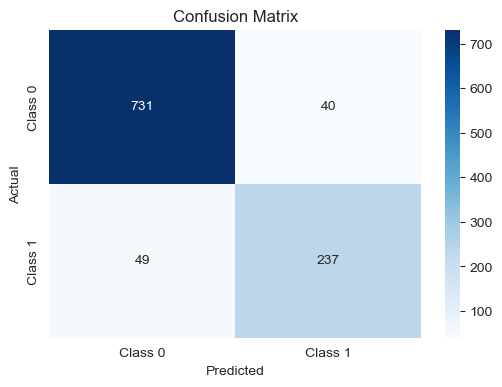

In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **Model Dashboard and Business Insights**

This dashboard summarizes the churn prediction workflow, model performance, and the key findings for stakeholders. It is designed to make the process easy to understand and highlight the most important signals from the model.

,Value
Total Records,7043.00
Churned Customers,1869.00
Retained Customers,5174.00
Churn Rate (%),26.54
Training Set Size,4930.00
Validation Set Size,1056.00
Test Set Size,1057.00
Baseline Accuracy (majority class),73.46


,Value
Validation Accuracy (%),92.9900
Test Accuracy (%),91.5800
Test ROC AUC,0.9758


,Precision,Recall,F1-score,Support
0,0.937179,0.948119,0.942618,771.000000
1,0.855596,0.828671,0.841918,286.000000
accuracy,0.915799,0.915799,0.915799,0.915799
macro avg,0.896388,0.888395,0.892268,1057.000000
weighted avg,0.915105,0.915799,0.915371,1057.000000


,Feature,Importance
19,Churn Score,0.382856
14,Contract,0.251220
3,Dependents,0.050531
8,Online Security,0.041501
4,Tenure Months,0.024267
15,Paperless Billing,0.021492
9,Online Backup,0.020992
2,Partner,0.019113
17,Monthly Charges,0.018994
11,Tech Support,0.018225


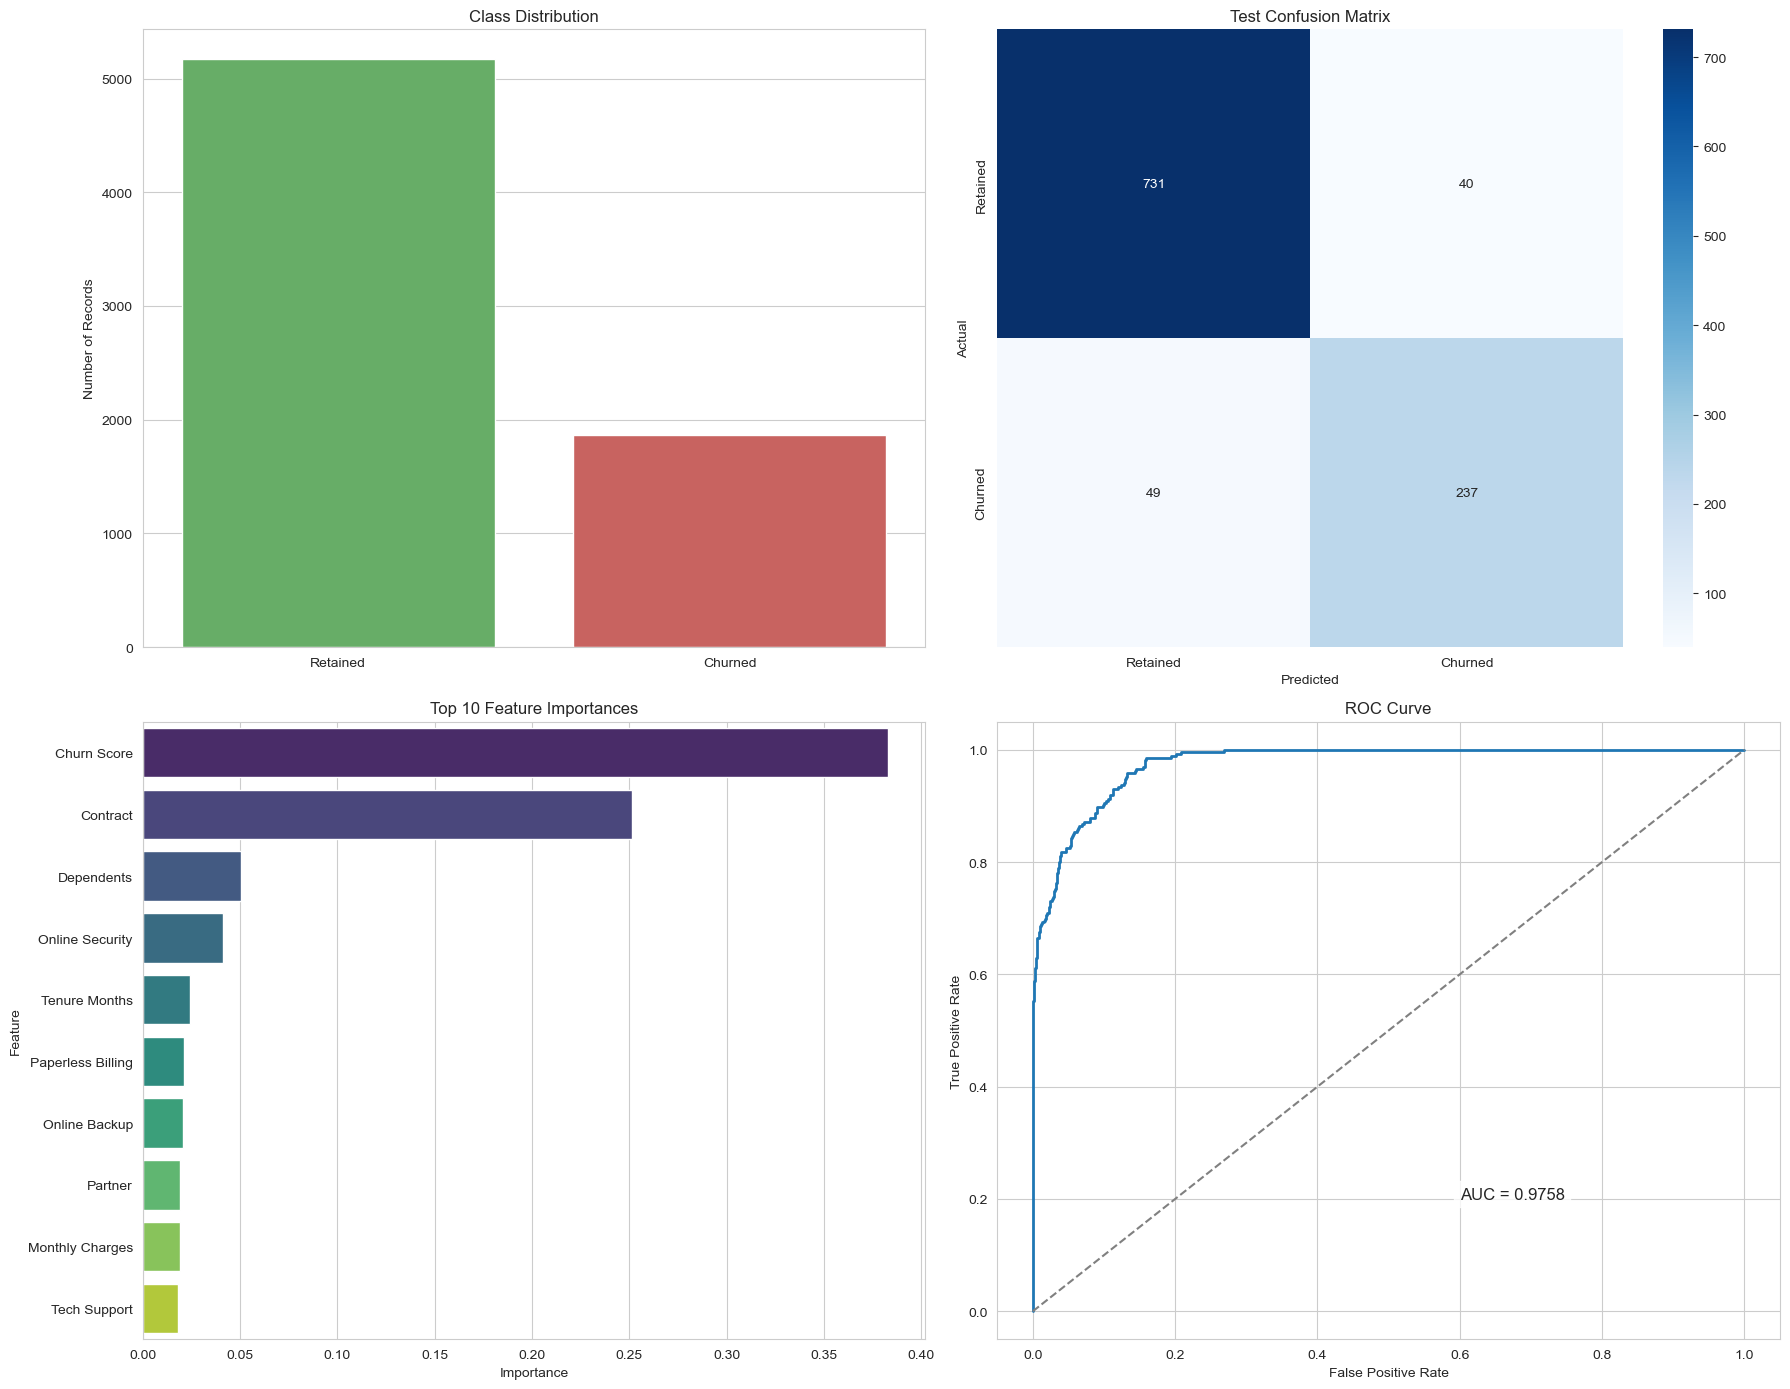

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 9)

# Dataset and split summary
summary = {
    'Total Records': len(df),
    'Churned Customers': int(y.sum()),
    'Retained Customers': int((y == 0).sum()),
    'Churn Rate (%)': round(100 * y.mean(), 2),
    'Training Set Size': X_train.shape[0],
    'Validation Set Size': X_val.shape[0],
    'Test Set Size': X_test.shape[0],
    'Baseline Accuracy (majority class)': round(max(y.value_counts(normalize=True)) * 100, 2)
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
display(summary_df)

# Performance metrics summary
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

performance = {
    'Validation Accuracy (%)': round(val_accuracy * 100, 2),
    'Test Accuracy (%)': round(test_accuracy * 100, 2)
}

try:
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_prob)
    performance['Test ROC AUC'] = round(test_auc, 4)
except Exception:
    y_test_prob = None

perf_df = pd.DataFrame.from_dict(performance, orient='index', columns=['Value'])
display(perf_df)

# Classification report for the test set
report_dict = classification_report(y_test, y_test_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_df = report_df.rename(columns={'precision': 'Precision', 'recall': 'Recall', 'f1-score': 'F1-score', 'support': 'Support'})
display(report_df[['Precision', 'Recall', 'F1-score', 'Support']])

# Feature importance from XGBoost
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Top features
top_features = feature_importance.head(10)
display(top_features)

# Plots setup
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Class distribution
class_counts = y.value_counts().sort_index()
sns.barplot(x=['Retained', 'Churned'], y=class_counts.values, palette=['#5cb85c', '#d9534f'], ax=axes[0, 0])
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_ylabel('Number of Records')

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'], ax=axes[0, 1])
axes[0, 1].set_title('Test Confusion Matrix')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Feature importance plot
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Top 10 Feature Importances')

# ROC curve if available
if y_test_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    axes[1, 1].plot(fpr, tpr, color='#1f77b4', linewidth=2)
    axes[1, 1].plot([0, 1], [0, 1], color='grey', linestyle='--')
    axes[1, 1].set_title('ROC Curve')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].text(0.6, 0.2, f'AUC = {performance.get("Test ROC AUC", "N/A")}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
else:
    axes[1, 1].text(0.5, 0.5, 'ROC curve unavailable', ha='center', va='center', fontsize=14)
    axes[1, 1].axis('off')

fig.tight_layout()
plt.show()

### **Dashboard Summary & Key Insights**

- **Workflow Overview:** We loaded the processed dataset, separated features and the churn label, split the data into training, validation, and test sets, scaled the numeric features, and trained an XGBoost classifier.
- **Model Performance:** Validation and test accuracy are shown above, along with the test classification report. A high AUC score indicates strong discrimination between churned and retained customers.
- **Most Influential Features:** The model reveals the strongest signals driving churn. The top features displayed are the most important levers for customer retention strategies.
- **Business Interpretation:** Use these insights to prioritize customer segments at highest churn risk (e.g., specific contract types, monthly charges, service usage patterns). This helps design targeted retention campaigns.
- **Next Steps:** Hyperparameter tuning, comparing additional models, and deploying the best model into a monitoring pipeline will further improve reliability and business value.

> Now we Have completed the model implementation.
on the next files, we will continue with the business Insights that will be proved beneficial to reduce the churn rate.

+ => [Business Insights (BI)](https://github.com/MOHSIN184/Telecom_Churn_Prediction/blob/main/6.%20Business_Insights.ipynb)
